# 03 · Modelling — class_action_sought & case_type

Two classification tasks on the cleaned case text (TF-IDF features):

1. **`class_action_sought`** — binary (Yes / No)
2. **`case_type`** — multi-class (12 civil-rights types)

Models: **Naive Bayes**, **Logistic Regression (GLM)**, **Linear SVM** and a **TensorFlow Bi-LSTM**. We train on train+dev and report on the held-out test split. (Full training incl. the LSTM is in `src/train_models.py`; here we retrain the fast linear models live and load the saved LSTM history.)

In [1]:
import sys, os, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.max_colwidth", 120)
import config as C
DF = pd.read_parquet(C.SUBSET_PARQUET)
print("Loaded subset:", DF.shape)
DF.head(2)


Loaded subset: (1915, 16)


,case_id,case_name,split,case_type,class_action_sought,court,state,filing_year,n_documents,n_clean_chars,full_text_raw,full_text_clean,summary_long,summary_short,summary_tiny,case_url
0,NS-NY-0008,ACLU v. FBI,train,National Security,No,Southern District of New York,New York,2011,7,115802,Case 1:11-cv-07562-WHP Document 1 Filed 10/26/11 Page 1 of 11\n\n0 UNITED STATES DISTRIC\n\nRT\n\n% SOUTHERN DISTRIC...,0 UNITED STATES DISTRIC\n\nRT\n\n% SOUTHERN DISTRICT OF NEW\n\nAMERICAN CIVIL LIBERTIES UNION 125 Broad Street New Y...,"On October 26, 2011, the ACLU filed a lawsuit in the U.S. District Court for the Southern District of New York again...","On October 26, 2011, the ACLU filed a lawsuit to compel the government to comply with a Freedom of Information Act r...",ACLU lawsuit versus FBI and Department of Justice results in the release of thousands of pages of documents related ...,https://clearinghouse.net/case/13769
1,FA-HI-0001,Hawaii Defense Foundation v. City and County of Honolulu,train,Speech and Religious Freedom,No,District of Hawaii,Hawaii,2012,5,117062,Case: 1:12-cv-00469-JMS-RLP As of: 01/23/2019 12:27 PM HST 1 of 10\nU.S. District Court District of Hawaii (Hawaii) ...,Case: 1:12-cv-00469-JMS-RLP As of: 01/23/2019 12:27 PM HST 1 of 10\nU.S. District Court District of Hawaii (Hawaii) ...,"On August 12, 2012, the Hawaii Defense Foundation and two of its members filed this lawsuit in the U.S. District Cou...","In 2012, the Hawaii Defense Foundation filed this complaint in the U.S. District Court for the District of Hawaii. P...",Lawsuit by the Hawaii Defense Foundation lead to private settlement and attorneys' fees (D. Haw.),https://clearinghouse.net/case/16977


In [2]:
from modeling import make_pipeline, evaluate, top_features_per_class
metrics = json.load(open(C.MODELS_DIR/"metrics.json"))
top_feats = json.load(open(C.MODELS_DIR/"top_features.json"))
DF["text"] = DF.full_text_clean.fillna("")

def split_xy(target):
    d = DF.copy()
    if target=="class_action_sought": d=d[d[target].isin(["Yes","No"])]
    d = d[d[target].astype(str).str.len()>0]
    tr=d[d.split.isin(["train","dev"])]; te=d[d.split=="test"]
    return (tr.text.tolist(), tr[target].astype(str).tolist(),
            te.text.tolist(), te[target].astype(str).tolist())

## 1. Train the linear models on both targets

In [3]:
fitted = {}
for target in ["class_action_sought","case_type"]:
    Xtr,ytr,Xte,yte = split_xy(target)
    labels = sorted(set(ytr)|set(yte))
    fitted[target] = {"data":(Xte,yte,labels), "pipes":{}}
    print(f"\n### {target}  (train={len(Xtr)} test={len(Xte)} classes={len(labels)})")
    for key in ["naive_bayes","logreg","linear_svm"]:
        pipe = make_pipeline(key).fit(Xtr,ytr)
        res = evaluate(key, yte, pipe.predict(Xte), labels=labels)
        fitted[target]["pipes"][key]=pipe
        print("   "+res.summary_line())


### class_action_sought  (train=1534 test=381 classes=2)


   naive_bayes    acc=0.882  macro-F1=0.867


   logreg         acc=0.945  macro-F1=0.938


   linear_svm     acc=0.950  macro-F1=0.943

### case_type  (train=1534 test=381 classes=12)


   naive_bayes    acc=0.761  macro-F1=0.728


   logreg         acc=0.895  macro-F1=0.889


   linear_svm     acc=0.911  macro-F1=0.905


## 2. Overall accuracy leaderboard (incl. the LSTM)
Linear models on TF-IDF beat the LSTM here: the documents are long and the subset is modest, so sparse bag-of-words features generalise better than a sequence model trained from scratch.

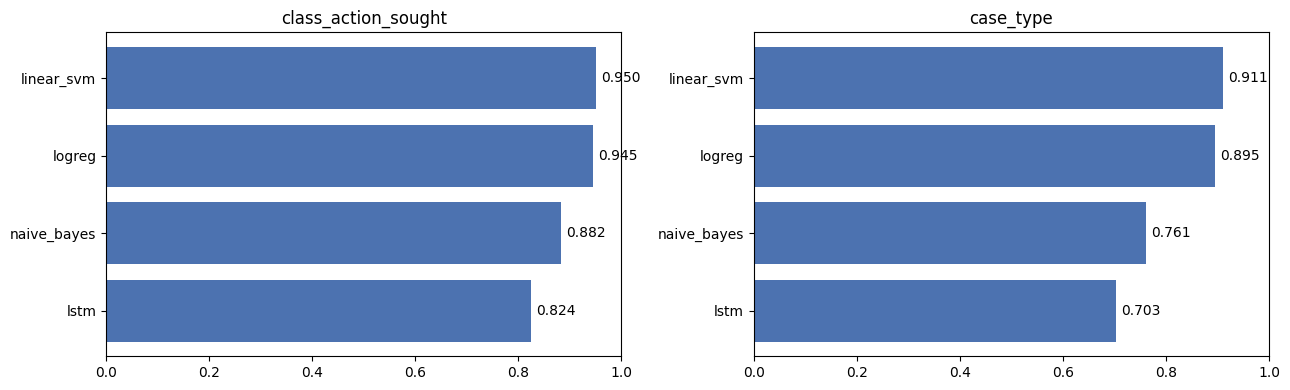

,target,model,accuracy,macro_f1
0,class_action_sought,naive_bayes,0.881890,0.866863
1,class_action_sought,logreg,0.944882,0.937619
2,class_action_sought,linear_svm,0.950131,0.943329
3,class_action_sought,lstm,0.824147,0.788727
4,case_type,naive_bayes,0.761155,0.728316
5,case_type,logreg,0.895013,0.888722
6,case_type,linear_svm,0.910761,0.905000
7,case_type,lstm,0.703412,0.690438


In [4]:
rows=[]
for target in metrics:
    for m,d in metrics[target]["models"].items():
        rows.append({"target":target,"model":m,"accuracy":d["accuracy"],"macro_f1":d["macro_f1"]})
lead = pd.DataFrame(rows)
fig,ax=plt.subplots(1,2,figsize=(13,4))
for i,t in enumerate(metrics):
    sub=lead[lead.target==t].sort_values("accuracy")
    ax[i].barh(sub.model, sub.accuracy, color="#4C72B0")
    ax[i].set_title(t); ax[i].set_xlim(0,1)
    for y,v in enumerate(sub.accuracy): ax[i].text(v+.01,y,f"{v:.3f}",va="center")
plt.tight_layout(); plt.show()
lead

## 3. Accuracy by genre/class (per-class accuracy)
The project asks for accuracy **by class**, not just overall. Below: per-class accuracy (recall) of the best model on each target.

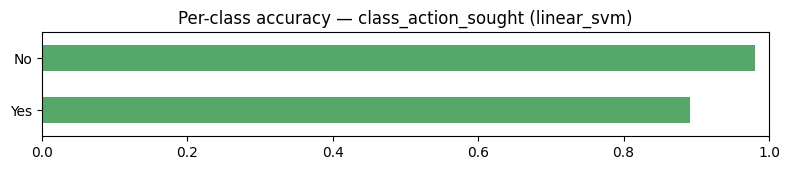

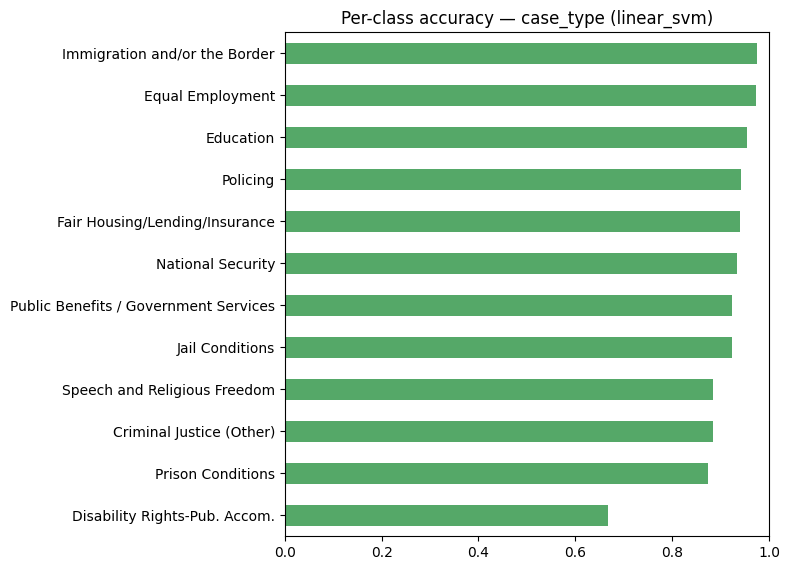

In [5]:
best = {"class_action_sought":"linear_svm","case_type":"linear_svm"}
for target,m in best.items():
    pca = metrics[target]["models"][m]["per_class_accuracy"]
    s = pd.Series(pca).sort_values()
    s.plot.barh(figsize=(8, 0.4*len(s)+1), color="#55A868")
    plt.title(f"Per-class accuracy — {target} ({m})"); plt.xlim(0,1)
    plt.tight_layout(); plt.show()

## 4. Confusion matrix (case_type, Linear SVM)

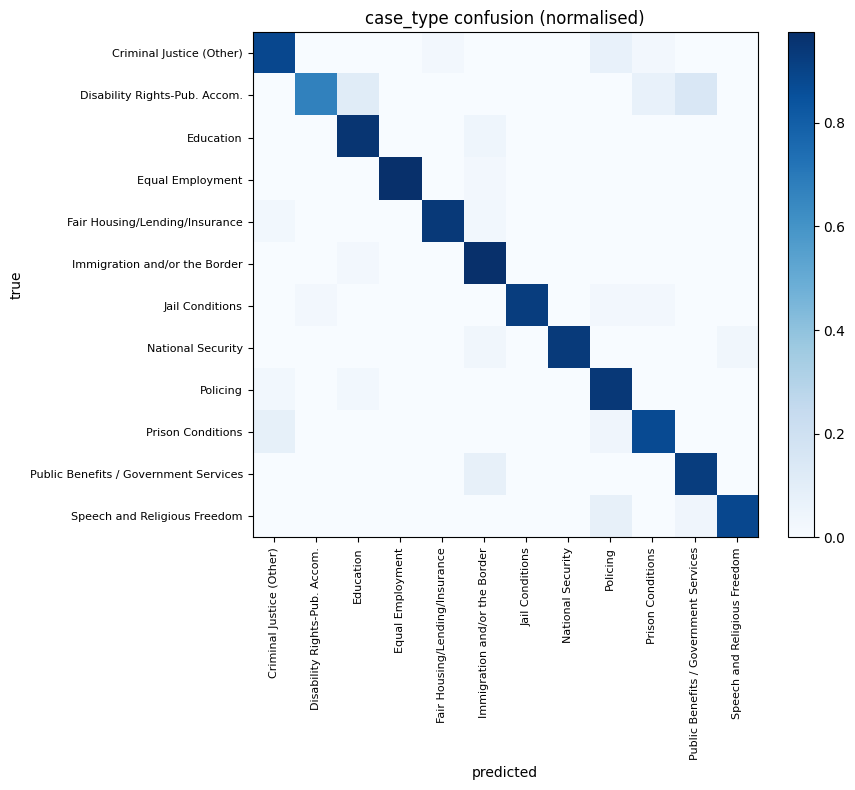

In [6]:
import numpy as np
cm = np.array(metrics["case_type"]["models"]["linear_svm"]["confusion"])
labs = metrics["case_type"]["labels"]
cmn = cm/cm.sum(axis=1,keepdims=True)
fig,ax=plt.subplots(figsize=(9,8))
im=ax.imshow(cmn,cmap="Blues"); plt.colorbar(im,fraction=0.046)
ax.set_xticks(range(len(labs))); ax.set_xticklabels(labs,rotation=90,fontsize=8)
ax.set_yticks(range(len(labs))); ax.set_yticklabels(labs,fontsize=8)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("case_type confusion (normalised)")
plt.tight_layout(); plt.show()

## 5. Most important words per class + word clouds
TF-IDF + linear models are interpretable: the highest-weighted features per class read like a glossary of each civil-rights area.

In [7]:
for cls, words in list(top_feats["case_type"]["logreg"].items())[:6]:
    print(f"{cls:38s}: {", ".join(words[:10])}")

Criminal Justice (Other)              : probation, parole, offender, offenders, sentenced, sex offender, offense, arrest, convicted, incarceration
Disability Rights-Pub. Accom.         : ada, disabilities, americans disabilities, disabilities act, disability, rehabilitation act, individuals disabilities, accessible, title iii, rehabilitation
Education                             : students, student, department education, schools, school, education, school year, educational, public schools, teacher
Equal Employment                      : title vii, eeoc, equal employment, employment opportunity, opportunity commission, employment practices, vii civil, unlawful employment, commission, vii
Fair Housing/Lending/Insurance        : fair housing, housing act, loan, fha, loans, housing, hud, rental, dwelling, mortgage
Immigration and/or the Border         : immigration, ice, immigrant, immigrants, homeland security, homeland, alien, customs enforcement, dhs, immigration customs


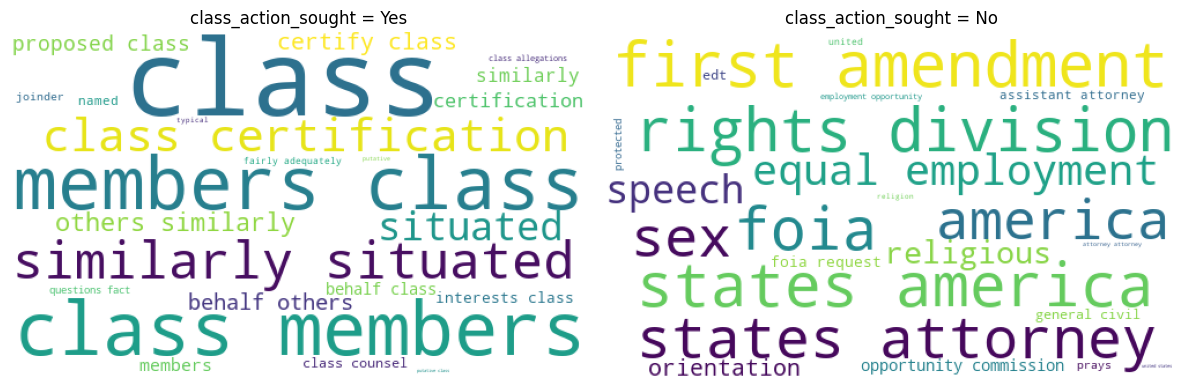

In [8]:
try:
    from wordcloud import WordCloud
    classes = ["Yes","No"]
    fig,ax=plt.subplots(1,2,figsize=(12,4))
    for i,cls in enumerate(classes):
        words = top_feats["class_action_sought"]["logreg"][cls]
        freqs = {w: len(words)-j for j,w in enumerate(words)}
        wc = WordCloud(width=500,height=300,background_color="white").generate_from_frequencies(freqs)
        ax[i].imshow(wc); ax[i].axis("off"); ax[i].set_title(f"class_action_sought = {cls}")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("wordcloud unavailable:", e)

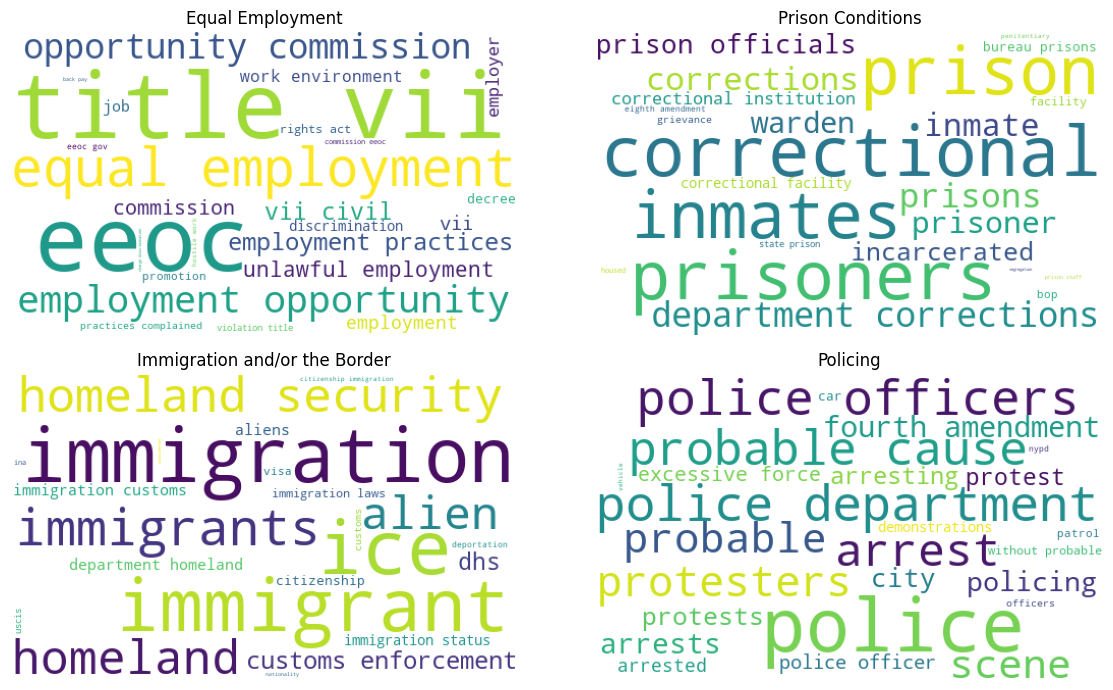

In [9]:
try:
    from wordcloud import WordCloud
    show = ["Equal Employment","Prison Conditions","Immigration and/or the Border","Policing"]
    fig,ax=plt.subplots(2,2,figsize=(12,7)); ax=ax.ravel()
    for i,cls in enumerate(show):
        words = top_feats["case_type"]["logreg"].get(cls,[])
        freqs = {w: len(words)-j for j,w in enumerate(words)}
        wc = WordCloud(width=500,height=300,background_color="white").generate_from_frequencies(freqs)
        ax[i].imshow(wc); ax[i].axis("off"); ax[i].set_title(cls)
    plt.tight_layout(); plt.show()
except Exception as e: print("wordcloud unavailable:", e)

## 6. The TensorFlow model: architecture & accuracy over epochs

In [10]:
from modeling import build_lstm
lstm = build_lstm(vocab_size=20000, maxlen=400, n_classes=12)
lstm.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 400, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 400, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,667,852 (10.18 MB)

 Trainable params: 2,667,852 (10.18 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Optional rendered diagram (needs graphviz+pydot). Falls back to the
# text summary above if those system deps are unavailable.
arch_png = C.MODELS_DIR / "lstm_arch.png"
try:
    from tensorflow.keras.utils import plot_model
    plot_model(lstm, to_file=str(arch_png), show_shapes=True)
except Exception as e:
    print("plot_model needs graphviz/pydot; using the text summary above.")
if arch_png.exists():
    from IPython.display import Image, display; display(Image(str(arch_png)))

You must install pydot (`pip install pydot`) for `plot_model` to work.


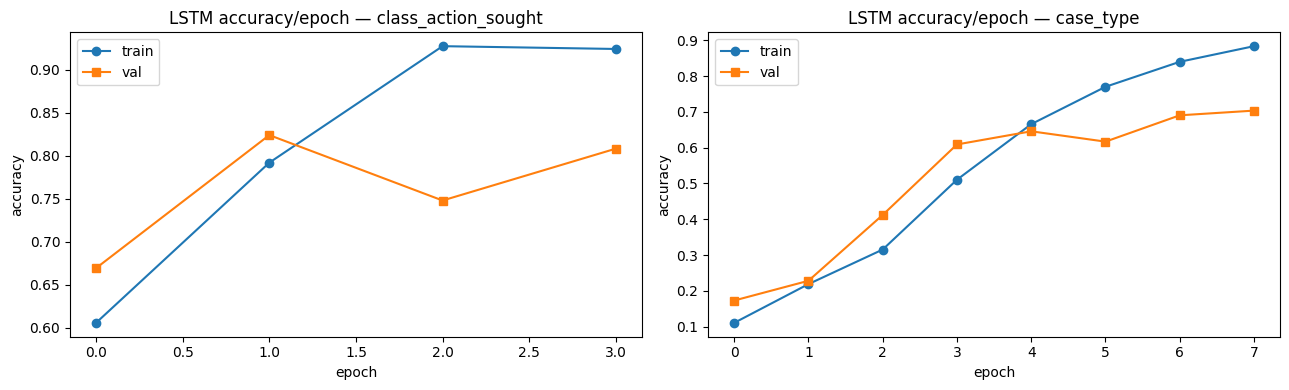

In [12]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
for i,target in enumerate(["class_action_sought","case_type"]):
    h = metrics[target]["models"]["lstm"]["history"]
    ax[i].plot(h["accuracy"], marker="o", label="train")
    ax[i].plot(h["val_accuracy"], marker="s", label="val")
    ax[i].set_title(f"LSTM accuracy/epoch — {target}"); ax[i].set_xlabel("epoch")
    ax[i].set_ylabel("accuracy"); ax[i].legend()
plt.tight_layout(); plt.show()

## 7. Where do the models disagree?
We compare Naive Bayes vs Linear SVM on `case_type` and inspect cases they label differently. Disagreements cluster on **overlapping civil-rights areas** (e.g. *Prison Conditions* vs *Jail Conditions*, or *Policing* vs *Criminal Justice*): NB weights individual indicative words and is swayed by frequent generic legal terms, while the margin-based SVM uses the whole weighted bag-of-words, so it separates the near-duplicate categories better.

In [13]:
Xte,yte,labels = fitted["case_type"]["data"]
nb_pred = fitted["case_type"]["pipes"]["naive_bayes"].predict(Xte)
svm_pred = fitted["case_type"]["pipes"]["linear_svm"].predict(Xte)
dis = pd.DataFrame({"true":yte,"naive_bayes":nb_pred,"linear_svm":svm_pred})
dis["snippet"]=[t[:160].replace(chr(10)," ") for t in Xte]
mask = dis.naive_bayes!=dis.linear_svm
print(f"{mask.sum()} / {len(dis)} test cases disagree between NB and SVM")
dis[mask].head(8)[["true","naive_bayes","linear_svm","snippet"]]

73 / 381 test cases disagree between NB and SVM


,true,naive_bayes,linear_svm,snippet
0,Immigration and/or the Border,Public Benefits / Government Services,Education,UNITED STATES DISTRICT COURT NORTHERN DISTRICT OF NEW YORK -------------------------------------------------------...
1,Education,Policing,Education,UNITED STATES DISTRICT COURT NORTHERN DISTRICT OF NEW YORK CHARLES PATRICK PRATT and A.E.P. through her parents and...
4,Immigration and/or the Border,Public Benefits / Government Services,Immigration and/or the Border,IN THE UNITED STATES DISTRICT COURT WESTERN DISTRICT OF TEXAS AUSTIN DIVISION Maria Isabel Perales Serna on her own...
6,Education,Public Benefits / Government Services,Education,2:16-cv-13694-AJT-APP Doc # 1 Filed 10/18/16 Pg 1 of 133 Pg ID 1 UNITED STATES DISTRICT COURT EASTERN DISTRICT OF M...
9,Fair Housing/Lending/Insurance,Public Benefits / Government Services,Fair Housing/Lending/Insurance,UNITED STATES DISTRICT COURT EASTERN DISTRICT OF NEW YORK --- X ACORN (THE NEW YORK ASSOCIATION OF COMMUNITY ORG...
10,Education,Public Benefits / Government Services,Education,"IN THE UNITED STATES DISTRICT COURT FOR THE EASTERN DISTRICT OF LOUISIANA ) P.B., by and through his next friend, ..."
14,Immigration and/or the Border,Equal Employment,Immigration and/or the Border,"UNITED STATES DISTRICT COURT FOR THE EASTERN DISTRICT OF LOUISIANA NEW ORLEANS DIVISION MOISES RODRIGUES, SERGIO OL..."
23,Criminal Justice (Other),Prison Conditions,Criminal Justice (Other),"Charles A. Brown Attorney at Law 324 Main Street P.O. Box 1225 Lewiston, ID 83501 208-746-9947 208-746-5886 (fax) IS..."


In [14]:
# which pairs of classes get confused between the two models
pairs = (dis[mask].groupby(["naive_bayes","linear_svm"]).size()
         .sort_values(ascending=False).head(8))
pairs

naive_bayes                            linear_svm                    
Public Benefits / Government Services  Education                         17
Prison Conditions                      Jail Conditions                    9
Public Benefits / Government Services  Fair Housing/Lending/Insurance     6
Prison Conditions                      Criminal Justice (Other)           5
Public Benefits / Government Services  Disability Rights-Pub. Accom.      5
Policing                               Education                          2
Prison Conditions                      Disability Rights-Pub. Accom.      2
National Security                      Immigration and/or the Border      2
dtype: int64

### Findings
* **Linear SVM** is the best model on both targets (class_action ≈ 0.95, case_type ≈ 0.91).
* The **GLM (logistic regression)** is a close second and the most calibrated → it is the default in the interactive tool.
* **Naive Bayes** trails because its independence assumption over long legal text over-counts generic terms.
* The **LSTM** underperforms the linear models on this subset size — long documents truncated to 400 tokens lose signal, and 1.5k examples is little for a sequence model trained from scratch.
* Per-class accuracy is high for distinctive types (Immigration, Equal Employment) and lowest for overlapping ones (Jail vs Prison Conditions).